In [1]:
import numpy as np
from dscribe.descriptors import MBTR
from matplotlib import pyplot as plt
import pickle

In [2]:
import pickle
with open('../gbs_ase.pickle', 'rb') as handle:
    my_ase = pickle.load(handle)

In [4]:
my_data = []

for i in range(len(my_ase)):
    desc = MBTR(
        species=["Al"],
        k2={
            "geometry": {"function": "distance"},
            "grid": {"min": 1, "max": 5, "sigma": 0.1, "n": 100},
            "weighting": {"function": "exp", "scale": 1.1, "threshold": 1e-2},
        },
        periodic=False,
        flatten=True,
        sparse=False,
        normalization="l2_each",
        )
    
    my_data.append(desc.create(my_ase[i]))
    del(desc)

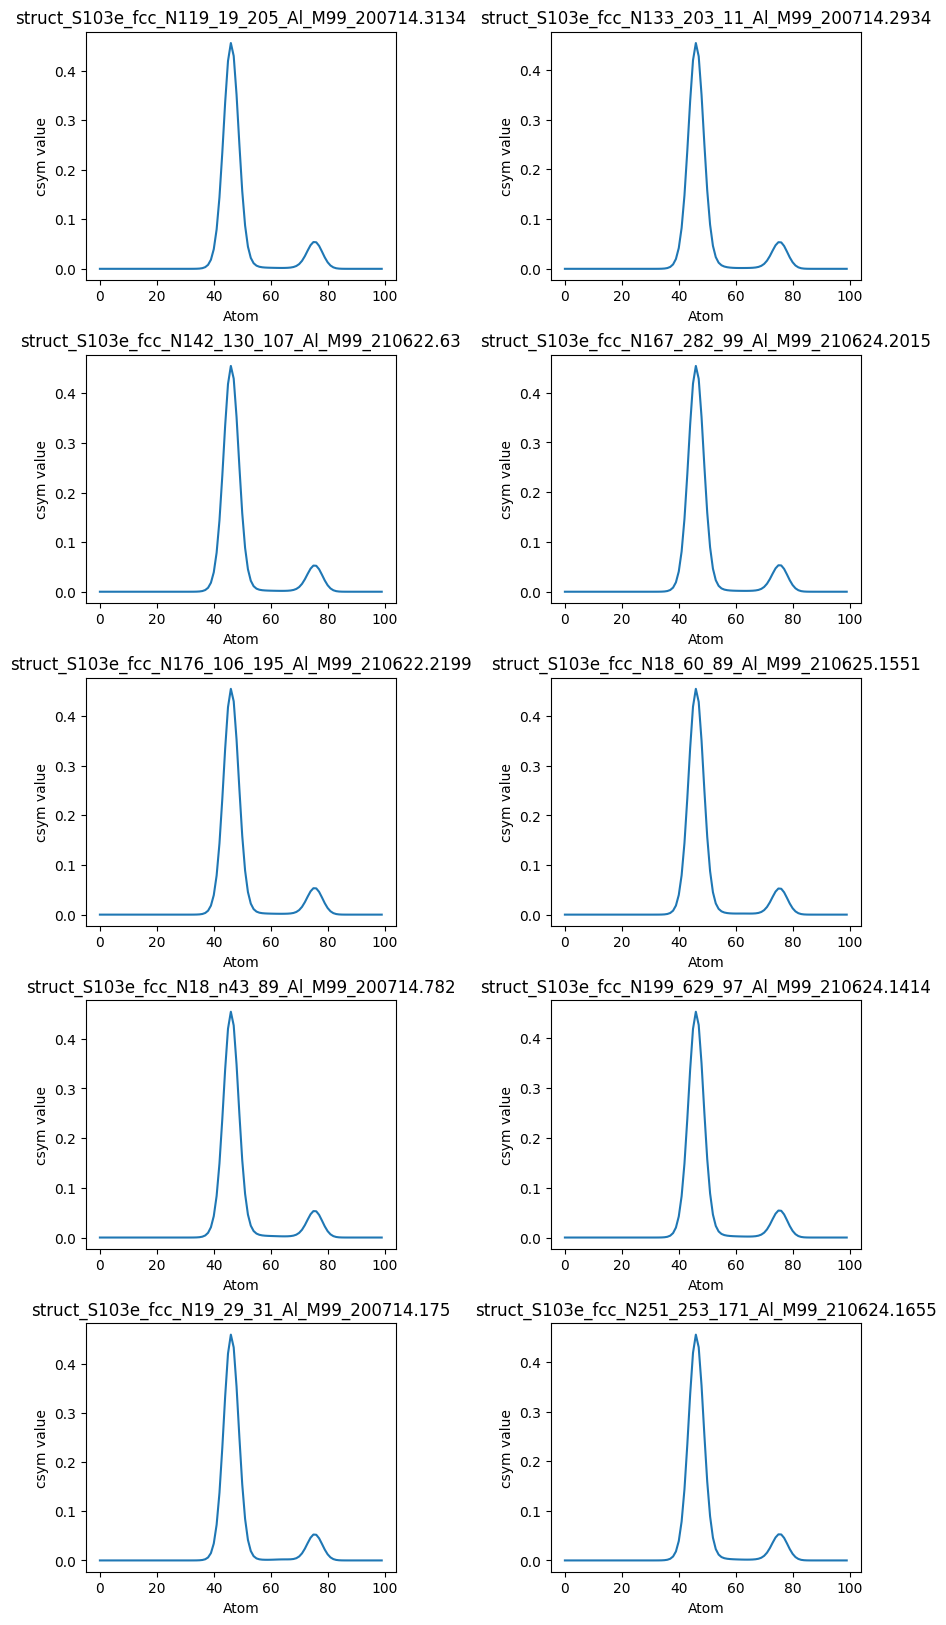

In [6]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(5, 2, figsize=(10, 20))
axs = axs.flatten()

for i, ax in enumerate(axs):
    ax.plot(range(len(my_data[i])),my_data[i])
    ax.set_title(my_ase[i].compute_id)
    ax.set_xlabel("Atom")
    ax.set_ylabel("csym value")
    
plt.subplots_adjust(wspace=0.5, hspace=0.3)

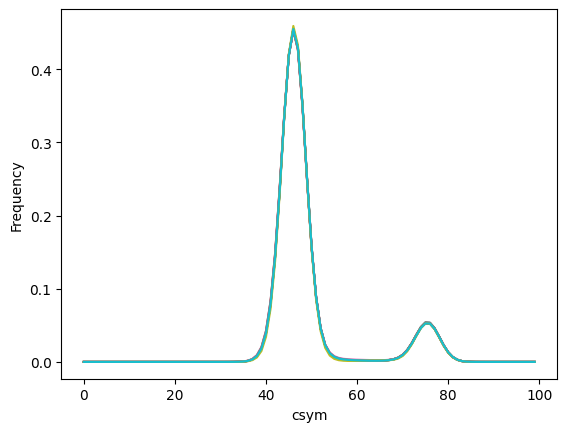

In [10]:
from scipy.stats import gaussian_kde

for i in range(len(my_ase)):
    kde = plt.plot(my_data[i])
    plt.xlabel("csym")
    plt.ylabel("Frequency")

Unfortunatly It doesn't look like MBTR can distinguish our grain boundaries

In [12]:
from sklearn.pipeline import make_pipeline, make_union
from tpot import TPOTRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_absolute_error


X = np.array(my_data)
y = np.load('../sample_energy.npy')

X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.75, test_size=0.25)

my_custom_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
tpot = TPOTRegressor(generations=5, population_size=50,verbosity=2,scoring=my_custom_scorer)
tpot.fit(X_train, y_train)
print(tpot.score(X_test, y_test))

                                                                              
Generation 1 - Current best internal CV score: -43.7
                                                                              
Generation 2 - Current best internal CV score: -43.7
                                                                              
Generation 3 - Current best internal CV score: -43.7
                                                                              
Generation 4 - Current best internal CV score: -43.7
                                                                              
Generation 5 - Current best internal CV score: -25.9
                                                                              
Best pipeline: AdaBoostRegressor(Nystroem(input_matrix, gamma=0.1, kernel=additive_chi2, n_components=2), learning_rate=0.001, loss=linear, n_estimators=100)
-27.0
